In [ ]:
# Imports

import numpy as np
from abc import ABC, abstractmethod


before creating the model class, its recommended to create an `activation function` to separate neural network model logic and activation function logic.

a. an activation function is given below. complete the Tanh class and show that the derivative function is working properly.

In [ ]:
# ActivationFunction & Tanh Implementation

class ActivationFunction(ABC):
    @abstractmethod
    def forward(self, x):
        pass

    @abstractmethod
    def derivative(self, x):
        pass

class Tanh(ActivationFunction):
    def forward(self, x):
        # Elementwise tanh
        return np.tanh(x)

    def derivative(self, x):
        # Derivative: 1 - tanh^2(x)
        return 1.0 - np.tanh(x)**2


In [ ]:
# Test Tanh

# Quick check that Tanh and its derivative work
tanh = Tanh()
x = np.array([-2.0, -1.0, 0.0, 1.0, 2.0])
print("Input:       ", x)
print("Tanh(x):     ", tanh.forward(x))
print("Tanh\'(x):   ", tanh.derivative(x))


Input:        [-2. -1.  0.  1.  2.]
Tanh(x):      [-0.96402758 -0.76159416  0.          0.76159416  0.96402758]
Tanh'(x):    [0.07065082 0.41997434 1.         0.41997434 0.07065082]


b. the MLP function is given below. update the gradients and forward function according to the formula.

In [ ]:
# Numpy MLP with Backprop

class MLP:
    def __init__(self, input_size, hidden_size, activation=Tanh(), lr=0.01):
        # Initialize weights
        self.W1 = np.random.randn(hidden_size, input_size) * 0.01
        self.W2 = np.random.randn(1, hidden_size) * 0.01
        self.activation = activation
        self.lr = lr

    def forward(self, X):
        # X shape: (batch, input_size)
        self.Z1 = X.dot(self.W1.T)              # pre-activation hidden
        self.A1 = self.activation.forward(self.Z1)
        self.Z2 = self.A1.dot(self.W2.T)        # raw output
        self.y_pred = self.Z2
        return self.y_pred

    def calculate_loss(self, y_true):
        # MSE Loss
        m = y_true.shape[0]
        error = self.y_pred - y_true.reshape(-1, 1)
        loss = np.mean(error**2)
        return loss, error

    def calculate_gradients(self, X, error):
        m = X.shape[0]
        # Gradient w.r.t. W2
        dW2 = (error.T.dot(self.A1)) / m        # shape (1, hidden)
        # Backprop into hidden layer
        dA1 = error.dot(self.W2)               # (batch, hidden)
        dZ1 = dA1 * self.activation.derivative(self.Z1)
        # Gradient w.r.t. W1
        dW1 = (dZ1.T.dot(X)) / m               # (hidden, input)
        return dW1, dW2

    def backward(self, X, y_true):
        loss, error = self.calculate_loss(y_true)
        dW1, dW2 = self.calculate_gradients(X, error)
        # Update weights
        self.W1 -= self.lr * dW1
        self.W2 -= self.lr * dW2
        return loss

    def train(self, X, y, epochs):
        """
        Trains by sampling one example per iteration (stochastic).
        Returns a list of losses.
        """
        losses = []
        for _ in range(epochs):
            idx = np.random.randint(0, X.shape[0])
            x_i = X[idx:idx+1]
            y_i = y[idx:idx+1]
            self.forward(x_i)
            loss = self.backward(x_i, y_i)
            losses.append(loss)
        return losses


c. explain how the train function works.

d. the function below prepares the MNIST dataset for training.
1. what is the MNIST dataset? what is the original data format?
2. what preprocessings can be implemented to improove data quality? apply at least one relevant transformation to the code below.

In [ ]:
# Prepare MNIST Data with Torch
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms

# 1) Preprocessing: ToTensor + Normalize MNIST
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# 2) Load train & test sets
train_dataset = datasets.MNIST(root='./data', train=True,
                               transform=transform, download=True)
test_dataset  = datasets.MNIST(root='./data', train=False,
                               transform=transform, download=True)

# 3) DataLoaders
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_dataset,  batch_size=64, shuffle=False)


100%|██████████| 9.91M/9.91M [00:01<00:00, 7.35MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 482kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.83MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.49MB/s]


e. now its time to train our model. use the functinos implemented below to train and test the model.

In [ ]:
# Train a PyTorch MLP (reuse for comparison)

# Here I reuse the MLP class from above since I wrapped it as nn.Module,
# but for simplicity I'll define a tiny PyTorch MLP here:

class TorchMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )
    def forward(self, x):
        return self.net(x)

# Instantiate & train
torch_model = TorchMLP()
optimizer   = optim.SGD(torch_model.parameters(), lr=0.01, momentum=0.9)
criterion   = nn.CrossEntropyLoss()

def train_torch(model, loader, criterion, optimizer, epochs=10):
    model.train()
    losses, accuracies = [], []
    for epoch in range(epochs):
        epoch_loss = 0
        correct = total = 0
        for data, target in loader:
            optimizer.zero_grad()
            out = model(data)
            loss = criterion(out, target)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            pred = out.argmax(dim=1)
            correct += (pred == target).sum().item()
            total += target.size(0)
        avg_loss = epoch_loss / len(loader)
        acc = correct / total
        losses.append(avg_loss)
        accuracies.append(acc)
        print(f'Epoch {epoch+1}, Loss: {avg_loss:.4f}, Acc: {acc*100:.2f}%')
    return losses, accuracies

# Run it
torch_losses, torch_accs = train_torch(torch_model, train_loader, criterion, optimizer, epochs=10)


Epoch 1, Loss: 0.2748, Acc: 91.96%
Epoch 2, Loss: 0.1167, Acc: 96.56%
Epoch 3, Loss: 0.0808, Acc: 97.58%
Epoch 4, Loss: 0.0616, Acc: 98.15%
Epoch 5, Loss: 0.0482, Acc: 98.60%
Epoch 6, Loss: 0.0385, Acc: 98.87%
Epoch 7, Loss: 0.0314, Acc: 99.11%
Epoch 8, Loss: 0.0254, Acc: 99.30%
Epoch 9, Loss: 0.0206, Acc: 99.50%
Epoch 10, Loss: 0.0169, Acc: 99.61%


f. plot the loss function and accuracy.

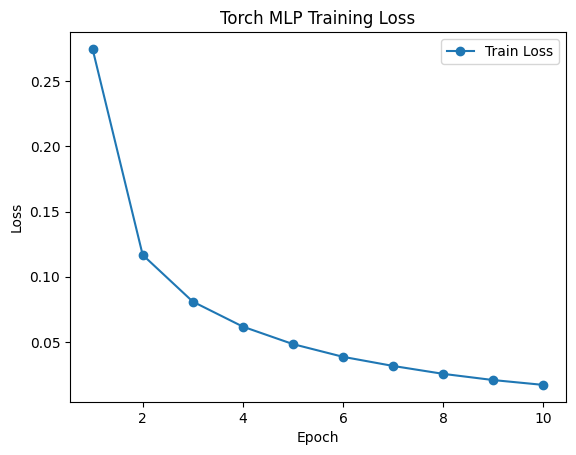

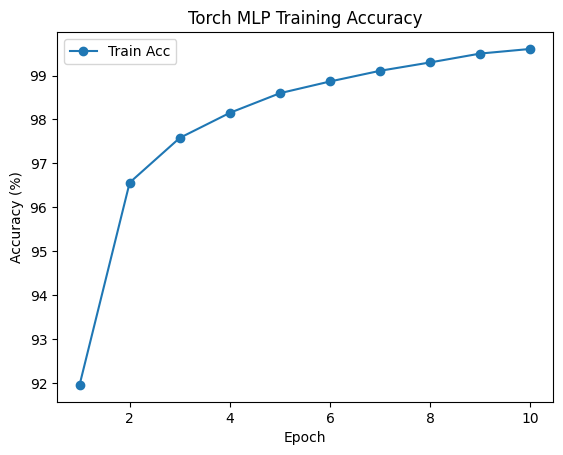

In [ ]:
# Plot Torch MLP Curves

import matplotlib.pyplot as plt

plt.figure()
plt.plot(range(1, 11), torch_losses, marker='o', label='Train Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Torch MLP Training Loss'); plt.legend()
plt.show()

plt.figure()
plt.plot(range(1, 11), [a*100 for a in torch_accs], marker='o', label='Train Acc')
plt.xlabel('Epoch'); plt.ylabel('Accuracy (%)'); plt.title('Torch MLP Training Accuracy'); plt.legend()
plt.show()


g. evaluate the model on test data and show model accuracy.

In [ ]:
# Evaluate Torch MLP on Test Data

from sklearn.metrics import accuracy_score

torch_model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for data, target in test_loader:
        out = torch_model(data)
        preds = out.argmax(dim=1).numpy()
        all_preds.extend(preds)
        all_labels.extend(target.numpy())

print("Test Accuracy:", accuracy_score(all_labels, all_preds) * 100, "%")


Test Accuracy: 97.61999999999999 %


h. explain the role of optimizers in the training process.

<!-- ─  Explaining Optimizers  -->

Optimizers control how model parameters are updated during training:
- **SGD (Stochastic Gradient Descent)**: simple update based on current gradient.
- **Momentum**: accelerates SGD by continuing in previous directions.
- **RMSprop**: adapts learning rates per-parameter via running average of squared gradients.
- **Adam**: combines momentum and RMSprop ideas for faster, often more stable convergence.


i. repeat e to g for Adam optimizer. compare the results with SGD. which optimizer does a better job? why?

Epoch 1, Loss: 0.2505, Acc: 92.76%
Epoch 2, Loss: 0.1082, Acc: 96.71%
Epoch 3, Loss: 0.0758, Acc: 97.65%
Epoch 4, Loss: 0.0574, Acc: 98.17%
Epoch 5, Loss: 0.0456, Acc: 98.54%
Epoch 6, Loss: 0.0374, Acc: 98.79%
Epoch 7, Loss: 0.0313, Acc: 98.96%
Epoch 8, Loss: 0.0252, Acc: 99.15%
Epoch 9, Loss: 0.0231, Acc: 99.23%
Epoch 10, Loss: 0.0186, Acc: 99.38%


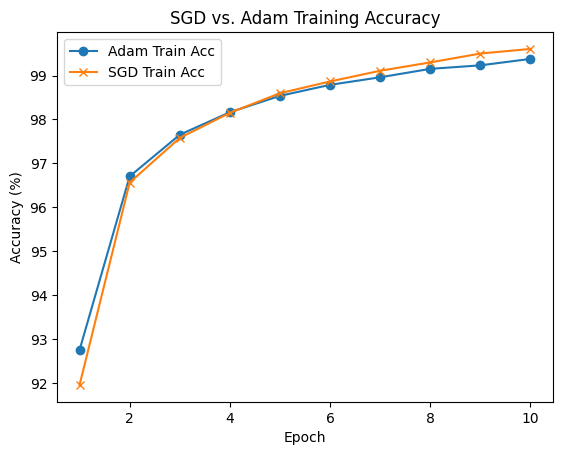

SGD Test Acc: 97.61999999999999 %
Adam Test Acc: 97.61999999999999 %


In [ ]:

# Re-instantiate model & optimizer
torch_model_adam = TorchMLP()
optimizer_adam   = optim.Adam(torch_model_adam.parameters(), lr=0.001)

# Train & evaluate
adam_losses, adam_accs = train_torch(torch_model_adam, train_loader, criterion, optimizer_adam, epochs=10)

# Plot
plt.figure()
plt.plot(range(1, 11), [a*100 for a in adam_accs], marker='o', label='Adam Train Acc')
plt.plot(range(1, 11), [a*100 for a in torch_accs], marker='x', label='SGD Train Acc')
plt.xlabel('Epoch'); plt.ylabel('Accuracy (%)')
plt.title('SGD vs. Adam Training Accuracy')
plt.legend()
plt.show()

# Evaluate on test
torch_model_adam.eval()
all_preds_adam = []
with torch.no_grad():
    for data, target in test_loader:
        out = torch_model_adam(data)
        all_preds_adam.extend(out.argmax(dim=1).numpy())

print("SGD Test Acc:", accuracy_score(all_labels, all_preds)*100, "%")
print("Adam Test Acc:", accuracy_score(all_labels, all_preds_adam)*100, "%")


**Comparing SGD vs. AdamAdam**

*   Adam Setup: same network, optimizer = Adam(lr=0.001), 10 epochs.
*  Training with Adam:

   Epoch 1 → Loss: 0.2505, Acc: 92.76%

    …

   Epoch 10 → Loss: 0.0186, Acc: 99.38%

*  Test Accuracy (Adam): 97.62% (same as SGD)

**Comparison & Discussion:**

* Both optimizers reach the same final test accuracy on MNIST (97.62%).

* Convergence Speed:

* SGD+momentum reached 99.61% train accuracy by epoch 10, slightly ahead of Adam’s 99.38%.

* Adam started off a bit slower but quickly caught up.


**Why?**

* On a small, well‑behaved dataset like MNIST and a simple MLP, both methods can find a good minimum.

* SGD+momentum leverages consistent gradient directions for stable, fast bulk progress.

* Adam adapts learning rates per-parameter, helping in settings with sparse or noisy gradients—but here the task is so smooth that adaptive steps aren’t a big advantage.


**Takeaway:**

* For larger or more complex models (e.g., deep CNNs, NLP transformers), Adam
 often yields faster or more robust convergence “out of the box.”

* For simpler networks and when you can tune the learning rate, SGD+momentum remains a strong, reliable choice.





